# ATIV-04-ET-01 – Análise do Dataset


## Upload do Dataset


In [ ]:
!ls


sample_data


## Descompactar o Dataset

In [ ]:
!unzip dataset-04.zip -d dataset

unzip:  cannot find or open dataset-04.zip, dataset-04.zip.zip or dataset-04.zip.ZIP.


In [ ]:
!ls

sample_data


## Ver o conteúdo da pasta dataset

In [ ]:
!ls dataset

ls: cannot access 'dataset': No such file or directory


# Descrição do Dataset

O dataset utilizado nesse projeto é destinado à tarefa de segmentação de imagens. É composto por um conjunto de imagens originais `Image`, suas respectivas máscaras de segmentação `Mask` e um arquivo de metadados `metadata.csv`.

As máscaras representam as regiões de interesse a serem identificadas pelo modelo. Esta etapa tem como objetivo analisar a integridade, qualidade e organização dos dados antes da etapa de modelagem.

In [ ]:
# Caso dê erro a célula abaixo, execute essa

!pip install kagglehub

In [2]:
# ============================================================
# CÉLULA DE CONFIGURAÇÃO DO DATASET
# Execute sempre esta célula ao abrir o notebook.
#
# Ela baixa automaticamente o dataset do Kaggle e define
# caminhos globais para imagens, máscaras e metadata.
#
# Todo o notebook deve usar essas constantes em vez de
# caminhos fixos como "dataset/Image", "dataset/Mask" e "dataset/metadata.csv".
# Isso garante portabilidade e evita erros de path.
# ============================================================

import kagglehub
import os # Necessário para PYTHONHASHSEED — controla o hash interno do Python
import random # Necessário para random.seed() — controla sorteios de amostras e splits
import numpy as np # Necessário para np.random.seed() — controla operações aleatórias do NumPy

# ==== Seed global ============================================================
# Define uma semente fixa para garantir reprodutibilidade:
# ao rodar o notebook novamente, os mesmos resultados serão obtidos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DATASET_PATH = kagglehub.dataset_download('faizalkarim/flood-area-segmentation')

# Caminhos
IMAGE_DIR = os.path.join(DATASET_PATH, 'Image') # Diretório das imagens
MASK_DIR = os.path.join(DATASET_PATH, 'Mask') # Diretório das máscaras
METADATA_PATH = os.path.join(DATASET_PATH, 'metadata.csv') # Arquivo CSV de metadados

print(f"Pasta de imagens: {IMAGE_DIR}")
print(f"Pasta de máscaras: {MASK_DIR}")
print(f"Arquivo de metadados: {METADATA_PATH}")

Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
Pasta de imagens: /kaggle/input/flood-area-segmentation/Image
Pasta de máscaras: /kaggle/input/flood-area-segmentation/Mask
Arquivo de metadados: /kaggle/input/flood-area-segmentation/metadata.csv


## 0. Visualização do Dataset

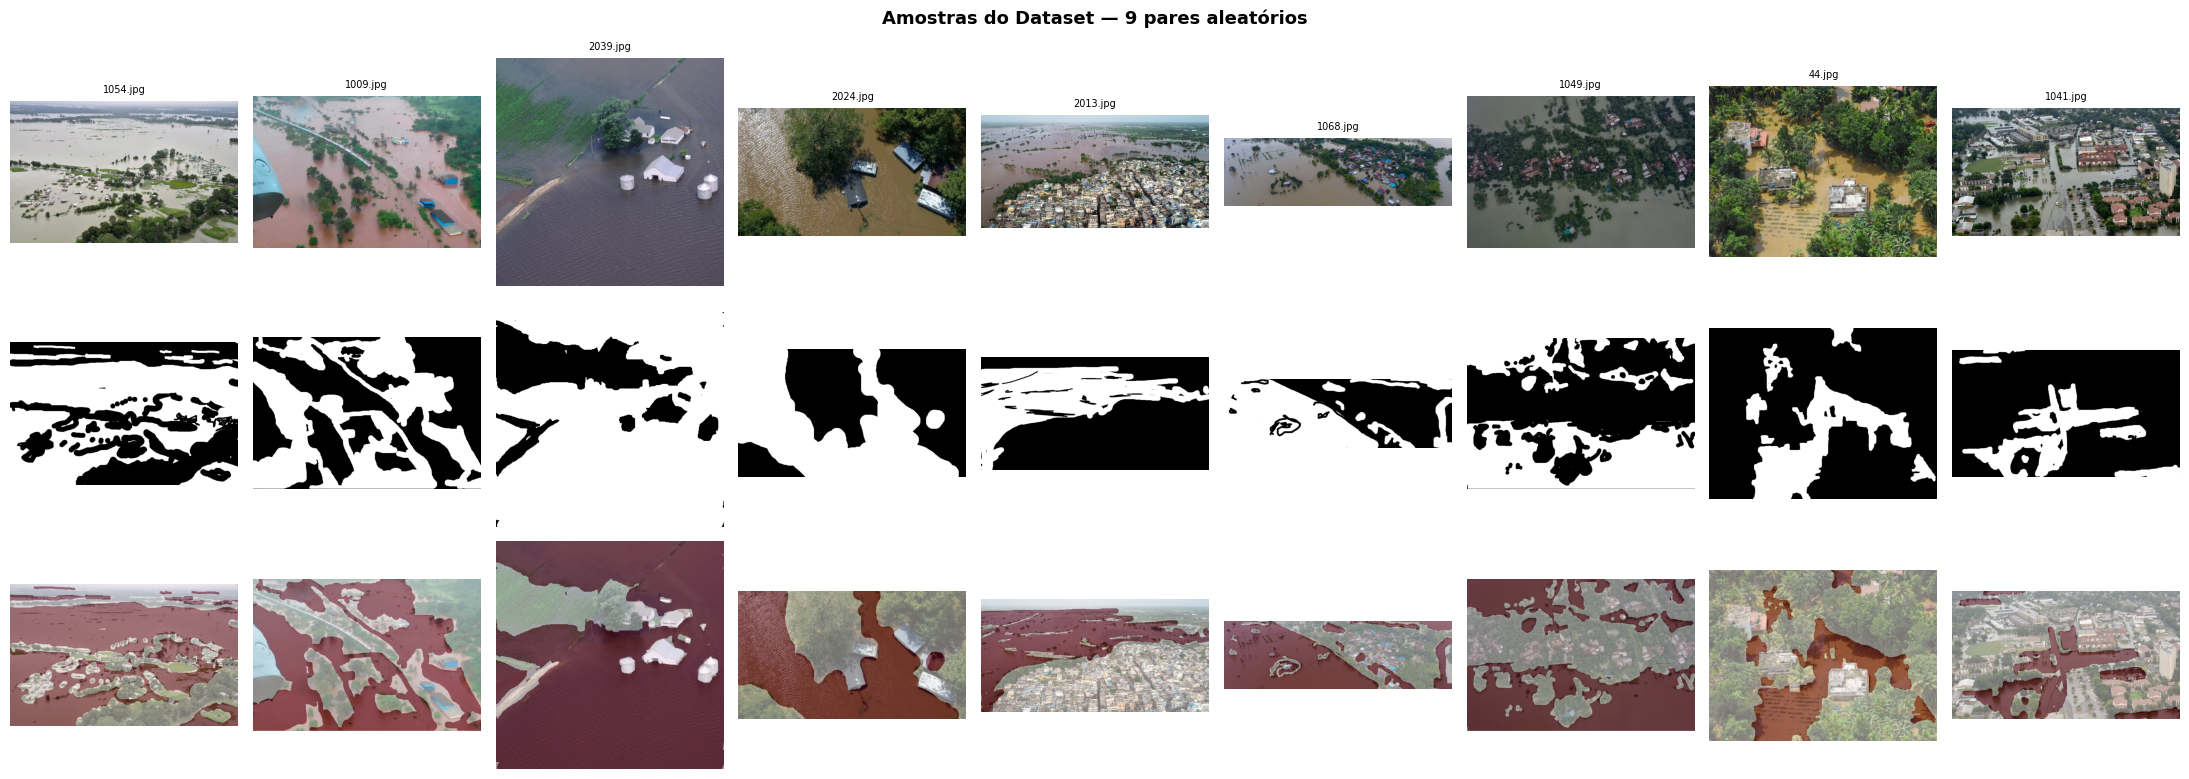

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

# random, numpy e SEED já importados/definidos na célula de configuração
mask_names = random.sample(sorted(os.listdir(MASK_DIR)), 9)

# 3 linhas x 9 colunas: Imagem Original | Máscara | Sobreposição
fig, axes = plt.subplots(3, 9, figsize=(22, 8))

for col, mask_name in enumerate(mask_names):
    base_name = os.path.splitext(mask_name)[0]
    img_name = base_name + ".jpg"

    img = np.array(Image.open(os.path.join(IMAGE_DIR, img_name)))
    mask = np.array(Image.open(os.path.join(MASK_DIR, mask_name)).convert("L"))
    mask_bin = (mask > 0).astype(np.uint8) * 255

    axes[0, col].imshow(img)
    axes[0, col].set_title(img_name, fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(mask_bin, cmap="gray")
    axes[1, col].axis("off")

    axes[2, col].imshow(img)
    axes[2, col].imshow(mask_bin, cmap="Reds", alpha=0.45)
    axes[2, col].axis("off")

for row, label in enumerate(["Imagem Original", "Máscara", "Sobreposição"]):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold", rotation=90, labelpad=10)

plt.suptitle("Amostras do Dataset — 9 pares aleatórios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Acima são exibidos 9 pares aleatórios do dataset, organizados em três linhas: a imagem original de área afetada por inundação, a máscara de segmentação binária correspondent (branco = área inundada, preto = fundo) e a sobreposição entre ambas. É possível observar a diversidade de cenários, além da variação na proporção e distribuição das regiões inundadas entre as amostras

## 1. Integridade dos Arquivos



### 1.1 Verificando se todas as imagens listadas no arquivo de informações existem no diretório e vice-versa

In [ ]:
import os
import pandas as pd

df = pd.read_csv(METADATA_PATH)

img_files = set(os.listdir(IMAGE_DIR))
mask_files = set(os.listdir(MASK_DIR))

img_missing = [f for f in df['Image'] if f not in img_files]
mask_missing = [f for f in df['Mask'] if f not in mask_files]

print("Linhas no metadata:", len(df))
print("Arquivos na pasta (Image):", len(img_files))
print("Arquivos na pasta (Mask):", len(mask_files))

print("Imagens do metadata que NÃO estão em Image:", len(img_missing))
print("Mascaras do metadata que NÃO estão em Mask:", len(mask_missing))

# arquivos na pasta que não estão no metadata
meta_images = set(df['Image'])
meta_masks  = set(df['Mask'])

extra_images = sorted(list(img_files - meta_images))
extra_masks  = sorted(list(mask_files - meta_masks))

print("Arquivos em Image que NÃO estão no metadata:", len(extra_images))
print("Arquivos em Mask que NÃO estão no metadata:", len(extra_masks))



Linhas no metadata: 290
Arquivos na pasta (Image): 290
Arquivos na pasta (Mask): 290
Imagens do metadata que NÃO estão em Image: 0
Mascaras do metadata que NÃO estão em Mask: 0
Arquivos em Image que NÃO estão no metadata: 0
Arquivos em Mask que NÃO estão no metadata: 0


### 1.2 Verificando o formato dos arquivos de imagem

In [ ]:
#teste
import pandas as pd

df = pd.read_csv(METADATA_PATH)
print(df.columns)
df.head()


Index(['Image', 'Mask'], dtype='object')


,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png


In [ ]:
from collections import Counter
import os

img_ext = Counter([os.path.splitext(f)[1].lower() for f in img_files])
mask_ext = Counter([os.path.splitext(f)[1].lower() for f in mask_files])

print("Extensões em Image:", img_ext)
print("Extensões em Mask:", mask_ext)


Extensões em Image: Counter({'.jpg': 290})
Extensões em Mask: Counter({'.png': 290})


### Resultado (Integridade e Formatos)

O arquivo metadata.csv contém 290 registros e foram encontrados 290 arquivos no diretório Image e 290 no diretório Mask.
Não foram identificados arquivos listados no metadata ausentes nas pastas, nem arquivos extras nas pastas que não estejam no metadata.

Quanto aos formatos, as imagens do diretório Image estão em .jpg e as máscaras do diretório Mask estão em .png,
mantendo consistência de formato dentro de cada diretório.


## 2. Consistência dos Metadados

### 2.1 Imports e Configurações

In [ ]:
import os
import pandas as pd
import numpy as np
import hashlib
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configurações de visualização
plt.style.use('ggplot')
sns.set_palette("husl")

df = pd.read_csv(METADATA_PATH)

print(f"Total de linhas no metadata: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nColunas disponíveis: {list(df.columns)}")
print("\n" + "="*60)
df.head(10)

Total de linhas no metadata: 290
Total de colunas: 2

Colunas disponíveis: ['Image', 'Mask']



,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png
5,5.jpg,5.png
6,6.jpg,6.png
7,7.jpg,7.png
8,8.jpg,8.png
9,9.jpg,9.png


### 2.2 Verificação de valores ausentes, duplicatas e iconsistências nos metadados

In [ ]:
print("ANÁLISE DE VALORES AUSENTES NO METADATA")
print("="*60)

# Verificar valores nulos
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Coluna': missing_values.index,
    'Valores Ausentes': missing_values.values,
    'Percentual (%)': missing_percentage.values
})

print(missing_df.to_string(index=False))

# Verificar valores vazios (strings vazias)
empty_images = df[df['Image'].astype(str).str.strip() == ''].shape[0]
empty_masks = df[df['Mask'].astype(str).str.strip() == ''].shape[0]

print(f"\nStrings vazias em 'Image': {empty_images}")
print(f"Strings vazias em 'Mask': {empty_masks}")

if missing_values.sum() == 0 and empty_images == 0 and empty_masks == 0:
    print("\nNenhum valor ausente encontrado.")
else:
    print("\nAtenção: valores ausentes detectados!")

ANÁLISE DE VALORES AUSENTES NO METADATA
Coluna  Valores Ausentes  Percentual (%)
 Image                 0             0.0
  Mask                 0             0.0

Strings vazias em 'Image': 0
Strings vazias em 'Mask': 0

Nenhum valor ausente encontrado.


In [ ]:
print("ANÁLISE DE DUPLICATAS NO METADATA")
print("="*60)

# Duplicatas completas (todas as colunas)
duplicates_full = df.duplicated()
print(f"Linhas completamente duplicadas: {duplicates_full.sum()}")

if duplicates_full.sum() > 0:
    print("\nLinhas duplicadas encontradas:")
    print(df[duplicates_full])


# Duplicatas na coluna 'Image'
duplicates_image = df['Image'].duplicated()
print(f"\nImagens duplicadas (coluna 'Image'): {duplicates_image.sum()}")

if duplicates_image.sum() > 0:
    print("\nImagens que aparecem mais de uma vez:")
    dup_images = df[df['Image'].duplicated(keep=False)].sort_values('Image')
    print(dup_images)

# Duplicatas na coluna 'Mask'
duplicates_mask = df['Mask'].duplicated()
print(f"\nMáscaras duplicadas (coluna 'Mask'): {duplicates_mask.sum()}")

if duplicates_mask.sum() > 0:
    print("\nMáscaras que aparecem mais de uma vez:")
    dup_masks = df[df['Mask'].duplicated(keep=False)].sort_values('Mask')
    print(dup_masks)

if duplicates_full.sum() == 0:
    print("\nNenhuma duplicata encontrada no metadata.")

ANÁLISE DE DUPLICATAS NO METADATA
Linhas completamente duplicadas: 0

Imagens duplicadas (coluna 'Image'): 0

Máscaras duplicadas (coluna 'Mask'): 0

Nenhuma duplicata encontrada no metadata.


In [ ]:
print("CONSISTÊNCIA: METADATA vs SISTEMA DE ARQUIVOS")
print("="*60)

# Listar arquivos nas pastas
img_files = set(os.listdir(IMAGE_DIR))
mask_files = set(os.listdir(MASK_DIR))

# Arquivos mencionados no metadata
meta_images = set(df['Image'])
meta_masks = set(df['Mask'])

# Arquivos faltando (no metadata mas não na pasta)
img_missing = sorted(list(meta_images - img_files))
mask_missing = sorted(list(meta_masks - mask_files))

# Arquivos extras (na pasta mas não no metadata)
extra_images = sorted(list(img_files - meta_images))
extra_masks = sorted(list(mask_files - meta_masks))

# Exibir resultados
print(f"\nArquivos na pasta 'Image': {len(img_files)}")
print(f"Arquivos na pasta 'Mask': {len(mask_files)}")
print(f"Imagens no metadata: {len(meta_images)}")
print(f"Máscaras no metadata: {len(meta_masks)}")

print("\n" + "-"*60)
print(f"Imagens do metadata que NÃO estão na pasta: {len(img_missing)}")
if img_missing:
    print(f"   Exemplos: {img_missing[:5]}")

print(f"\nMáscaras do metadata que NÃO estão na pasta: {len(mask_missing)}")
if mask_missing:
    print(f"   Exemplos: {mask_missing[:5]}")

print("\n" + "-"*60)
print(f"Arquivos na pasta 'Image' que NÃO estão no metadata: {len(extra_images)}")
if extra_images:
    print(f"   Exemplos: {extra_images[:5]}")

print(f"\nArquivos na pasta 'Mask' que NÃO estão no metadata: {len(extra_masks)}")
if extra_masks:
    print(f"   Exemplos: {extra_masks[:5]}")

if len(img_missing) == 0 and len(mask_missing) == 0 and len(extra_images) == 0 and len(extra_masks) == 0:
    print("\nMetadata e arquivos são consistentes.")

CONSISTÊNCIA: METADATA vs SISTEMA DE ARQUIVOS

Arquivos na pasta 'Image': 290
Arquivos na pasta 'Mask': 290
Imagens no metadata: 290
Máscaras no metadata: 290

------------------------------------------------------------
Imagens do metadata que NÃO estão na pasta: 0

Máscaras do metadata que NÃO estão na pasta: 0

------------------------------------------------------------
Arquivos na pasta 'Image' que NÃO estão no metadata: 0

Arquivos na pasta 'Mask' que NÃO estão no metadata: 0

Metadata e arquivos são consistentes.


Resumo:

## 3. Qualidade das Imagens

### 3.1 Verificação de imagens corrompidas e análise de dimensões

In [ ]:
def check_corrupted(folder, desc="Imagens"):
    corrupted = []
    files = os.listdir(folder)

    for file in tqdm(files, desc=f"Verificando {desc}"):
        path = os.path.join(folder, file)
        try:
            with Image.open(path) as img:
                img.verify()  # Verifica integridade
        except Exception as e:
            corrupted.append({'file': file, 'error': str(e)})

    return corrupted

print("VERIFICANDO QUALIDADE DAS IMAGENS")
print("="*60)

corrupted_images = check_corrupted(IMAGE_DIR, "Imagens")
corrupted_masks = check_corrupted(MASK_DIR, "Máscaras")

print(f"\nImagens corrompidas: {len(corrupted_images)}")
if corrupted_images:
    print("   Arquivos com problema:")
    for item in corrupted_images[:10]:
        print(f"   - {item['file']}: {item['error']}")

print(f"\nMáscaras corrompidas: {len(corrupted_masks)}")
if corrupted_masks:
    print("   Arquivos com problema:")
    for item in corrupted_masks[:10]:
        print(f"   - {item['file']}: {item['error']}")

if len(corrupted_images) == 0 and len(corrupted_masks) == 0:
    print("\nTodas as imagens e máscaras estão íntegras.")

VERIFICANDO QUALIDADE DAS IMAGENS


Verificando Máscaras: 100%|██████████| 290/290 [00:02<00:00, 124.16it/s]


Imagens corrompidas: 0

Máscaras corrompidas: 0

Todas as imagens e máscaras estão íntegras.


In [ ]:
def get_image_sizes(folder, desc="Imagens"):
    sizes = []
    files = os.listdir(folder)

    for file in tqdm(files, desc=f"Analisando dimensões - {desc}"):
        path = os.path.join(folder, file)
        try:
            with Image.open(path) as img:
                sizes.append({'file': file, 'width': img.width, 'height': img.height})
        except:
            sizes.append({'file': file, 'width': None, 'height': None})

    return pd.DataFrame(sizes)

print("ANÁLISE DE DIMENSÕES")
print("="*60)

image_sizes_df = get_image_sizes(IMAGE_DIR, "Imagens")
mask_sizes_df = get_image_sizes(MASK_DIR, "Máscaras")

# Dimensões únicas
unique_image_sizes = image_sizes_df.dropna()[['width', 'height']].drop_duplicates()
unique_mask_sizes = mask_sizes_df.dropna()[['width', 'height']].drop_duplicates()

print(f"\nDimensões únicas nas imagens: {len(unique_image_sizes)}")
print(f"Dimensões únicas nas máscaras: {len(unique_mask_sizes)}")

# Estatísticas
print("\nEstatísticas das Imagens:")
print(image_sizes_df[['width', 'height']].describe())

print("\nEstatísticas das Máscaras:")
print(mask_sizes_df[['width', 'height']].describe())

ANÁLISE DE DIMENSÕES


Analisando dimensões - Máscaras: 100%|██████████| 290/290 [00:00<00:00, 1181.64it/s]


Dimensões únicas nas imagens: 201
Dimensões únicas nas máscaras: 200

Estatísticas das Imagens:
             width       height
count   290.000000   290.000000
mean   1155.179310   732.682759
std     906.546274   595.548158
min     330.000000   219.000000
25%     635.500000   414.000000
50%     900.000000   540.000000
75%    1200.000000   743.250000
max    5472.000000  3648.000000

Estatísticas das Máscaras:
             width       height
count   290.000000   290.000000
mean   1158.782759   733.696552
std     907.362182   595.808367
min     330.000000   219.000000
25%     635.500000   414.000000
50%     900.000000   540.000000
75%    1200.000000   749.000000
max    5472.000000  3648.000000


### 3.2 Análise Detalhada de Dimensões e Outliers

In [ ]:
def analyze_image_dimensions_detailed(image_dir, mask_dir):
    """
    Análise detalhada das dimensões das imagens e máscaras.
    Identifica outliers e inconsistências.
    """
    print("Analisando dimensões detalhadas...\n")

    dimensions_data = {
        'image_name': [],
        'img_width': [],
        'img_height': [],
        'mask_width': [],
        'mask_height': [],
        'dimensions_match': [],
        'aspect_ratio': []
    }

    image_files = sorted(os.listdir(image_dir))

    for img_file in image_files:
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(image_dir, img_file)
        base_name = os.path.splitext(img_file)[0]

        possible_masks = [
            base_name + ".png",
            base_name + ".jpg",
            base_name + ".jpeg"
        ]

        mask_path = None
        for m in possible_masks:
            temp_path = os.path.join(mask_dir, m)
            if os.path.exists(temp_path):
                mask_path = temp_path
                break

        try:
            # Ler imagem
            img = Image.open(img_path)
            img_w, img_h = img.size

            # Ler máscara
            if os.path.exists(mask_path):
                mask = Image.open(mask_path)
                mask_w, mask_h = mask.size
            else:
                mask_w, mask_h = None, None

            # Calcular aspect ratio
            aspect_ratio = img_w / img_h if img_h > 0 else None

            # Verificar se dimensões coincidem
            match = (img_w == mask_w and img_h == mask_h) if mask_w is not None else False

            dimensions_data['image_name'].append(img_file)
            dimensions_data['img_width'].append(img_w)
            dimensions_data['img_height'].append(img_h)
            dimensions_data['mask_width'].append(mask_w)
            dimensions_data['mask_height'].append(mask_h)
            dimensions_data['dimensions_match'].append(match)
            dimensions_data['aspect_ratio'].append(aspect_ratio)

        except Exception as e:
            print(f"Erro ao processar {img_file}: {e}")

    df = pd.DataFrame(dimensions_data)

    # Estatísticas
    print("ESTATÍSTICAS DAS DIMENSÕES:")
    print("="*60)
    print(f"\nLargura das Imagens:")
    print(df['img_width'].describe())
    print(f"\nAltura das Imagens:")
    print(df['img_height'].describe())
    print(f"\nAspect Ratio:")
    print(df['aspect_ratio'].describe())

    # Identificar outliers usando IQR
    def find_outliers(series, name):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = series[(series < lower) | (series > upper)]
        if len(outliers) > 0:
            print(f"\nOutliers em {name}: {len(outliers)} casos")
            print(f"  Valores: {outliers.unique()}")
        return outliers

    print("\nANÁLISE DE OUTLIERS:")
    print("="*60)
    find_outliers(df['img_width'], 'Largura')
    find_outliers(df['img_height'], 'Altura')
    find_outliers(df['aspect_ratio'], 'Aspect Ratio')

    # Verificar dimensões que não coincidem
    mismatches = df[~df['dimensions_match']]
    if len(mismatches) > 0:
        print(f"\nINCONSISTÊNCIAS: {len(mismatches)} pares imagem-máscara com dimensões diferentes!")
        print(mismatches[['image_name', 'img_width', 'img_height', 'mask_width', 'mask_height']].head(10))
    else:
        print("\nTodas as imagens e máscaras têm dimensões correspondentes!")

    return df

# Executar análise
dimensions_df = analyze_image_dimensions_detailed(IMAGE_DIR, MASK_DIR)

Analisando dimensões detalhadas...

ESTATÍSTICAS DAS DIMENSÕES:

Largura das Imagens:
count     290.000000
mean     1155.179310
std       906.546274
min       330.000000
25%       635.500000
50%       900.000000
75%      1200.000000
max      5472.000000
Name: img_width, dtype: float64

Altura das Imagens:
count     290.000000
mean      732.682759
std       595.548158
min       219.000000
25%       414.000000
50%       540.000000
75%       743.250000
max      3648.000000
Name: img_height, dtype: float64

Aspect Ratio:
count    290.000000
mean       1.623684
std        0.307964
min        0.667368
25%        1.500000
50%        1.602136
75%        1.777778
max        3.465753
Name: aspect_ratio, dtype: float64

ANÁLISE DE OUTLIERS:

Outliers em Largura: 30 casos
  Valores: [2100 5184 5000 2200 2400 2560 4095 2981 3992 4859 3160 2733 2500 3500
 2231 3200 4640 3000 3840 2503 5472]

Outliers em Altura: 39 casos
  Valores: [1367 1400 3456 3333 1500 1467 1800 1333 1425 1316 2505 1478 2242 364

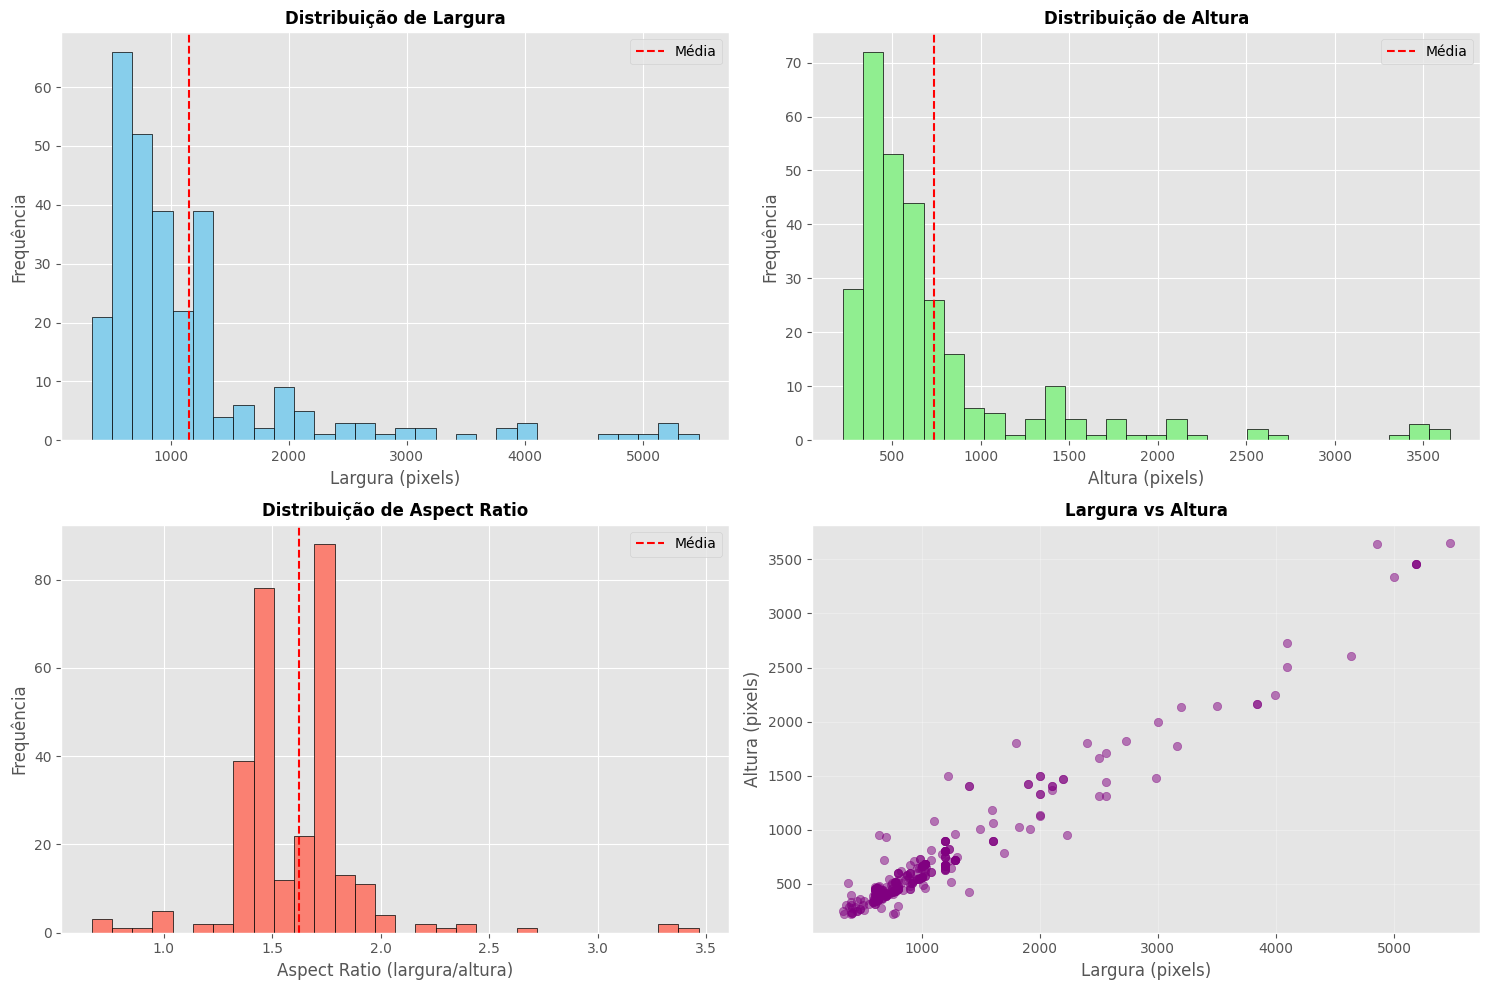

In [ ]:
# Visualizar distribuição de dimensões
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Largura
axes[0, 0].hist(dimensions_df['img_width'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribuição de Largura', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Largura (pixels)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].axvline(dimensions_df['img_width'].mean(), color='red', linestyle='--', label='Média')
axes[0, 0].legend()

# Altura
axes[0, 1].hist(dimensions_df['img_height'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribuição de Altura', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Altura (pixels)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].axvline(dimensions_df['img_height'].mean(), color='red', linestyle='--', label='Média')
axes[0, 1].legend()

# Aspect Ratio
axes[1, 0].hist(dimensions_df['aspect_ratio'], bins=30, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribuição de Aspect Ratio', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Aspect Ratio (largura/altura)')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].axvline(dimensions_df['aspect_ratio'].mean(), color='red', linestyle='--', label='Média')
axes[1, 0].legend()

# Scatter: Largura vs Altura
axes[1, 1].scatter(dimensions_df['img_width'], dimensions_df['img_height'], alpha=0.5, color='purple')
axes[1, 1].set_title('Largura vs Altura', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Largura (pixels)')
axes[1, 1].set_ylabel('Altura (pixels)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A base contém 290 imagens com alta variação de resolução. A largura média é 1155 px e a altura média 733 px, com grande dispersão devido à presença de imagens muito grandes.

O aspect ratio médio de 1,62 indica predominância de imagens no formato horizontal.

Foram identificados outliers relevantes (30 em largura, 39 em altura e 18 em aspect ratio), que podem impactar etapas de padronização ou treinamento.

Também foram encontrados 7 pares imagem-máscara com dimensões divergentes, porém as máscaras correspondem corretamente às imagens, sendo necessário apenas ajuste de dimensionamento.

### 3.3 Verificação de Imagens Corrompidas

In [ ]:
import os
from PIL import Image

def check_corrupted_images(image_dir, mask_dir):
    """
    Verifica imagens e máscaras realmente corrompidas usando PIL.verify().
    Retorna listas com arquivos problemáticos.
    """

    print("Verificando arquivos...\n")

    corrupted_images = []
    corrupted_masks = []

    def check_folder(folder_path, corrupted_list, folder_name):
        if not os.path.exists(folder_path):
            print(f"Pasta não encontrada: {folder_path}")
            return

        files = os.listdir(folder_path)
        print(f"{folder_name}: {len(files)} arquivos encontrados")

        for file in files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            path = os.path.join(folder_path, file)

            # Verifica tamanho 0 (arquivo vazio)
            if os.path.getsize(path) == 0:
                corrupted_list.append((file, "Arquivo vazio"))
                continue

            try:
                with Image.open(path) as img:
                    img.verify()  # Verifica integridade
            except Exception as e:
                corrupted_list.append((file, str(e)))

    # Verificar imagens
    check_folder(image_dir, corrupted_images, "Imagens")

    # Verificar máscaras
    check_folder(mask_dir, corrupted_masks, "Máscaras")

    # Resultado
    print("\n" + "="*50)
    print("RESULTADO FINAL")
    print("="*50)

    print(f"\nImagens corrompidas: {len(corrupted_images)}")
    if corrupted_images:
        for img, err in corrupted_images[:10]:
            print(f" - {img}: {err}")

    print(f"\nMáscaras corrompidas: {len(corrupted_masks)}")
    if corrupted_masks:
        for msk, err in corrupted_masks[:10]:
            print(f" - {msk}: {err}")

    return corrupted_images, corrupted_masks


# Executar
corrupted_imgs, corrupted_msks = check_corrupted_images(IMAGE_DIR, MASK_DIR)

Verificando arquivos...

Imagens: 290 arquivos encontrados
Máscaras: 290 arquivos encontrados

RESULTADO FINAL

Imagens corrompidas: 0

Máscaras corrompidas: 0


Foram verificados 290 arquivos de imagens e 290 arquivos de máscaras, havendo correspondência completa entre eles. Não foram identificados arquivos corrompidos em nenhum dos conjuntos, indicando que o dataset está íntegro e estruturalmente consistente.

### 3.4 Análise de Qualidade Visual (Blur, Contraste, Brilho)

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.ndimage import laplace

def analyze_image_quality(image_dir, sample_size=290):
    """
    Analisa qualidade visual: blur, contraste e brilho.
    Sem usar OpenCV.
    """

    print(f"Analisando qualidade visual de até {sample_size} imagens...\n")

    quality_data = {
        'image_name': [],
        'blur_score': [],
        'contrast': [],
        'brightness': []
    }

    image_files = sorted(os.listdir(image_dir))
    count = 0

    for img_file in image_files:
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        if count >= sample_size:
            break

        img_path = os.path.join(image_dir, img_file)

        try:
            # Abrir com PIL e converter para grayscale
            with Image.open(img_path) as img:
                img_gray = img.convert("L")
                img_array = np.array(img_gray)

            # Blur → variância do Laplaciano
            blur_score = laplace(img_array).var()

            # Contraste → desvio padrão
            contrast = np.std(img_array)

            # Brilho → média
            brightness = np.mean(img_array)

            quality_data['image_name'].append(img_file)
            quality_data['blur_score'].append(blur_score)
            quality_data['contrast'].append(contrast)
            quality_data['brightness'].append(brightness)

            count += 1

        except Exception as e:
            print(f"Erro ao processar {img_file}: {e}")

    df = pd.DataFrame(quality_data)

    if df.empty:
        print("Nenhuma imagem válida foi processada.")
        return df

    print("ESTATÍSTICAS DE QUALIDADE")
    print("="*50)
    print("\nBlur Score:")
    print(df['blur_score'].describe())
    print("\nContraste:")
    print(df['contrast'].describe())
    print("\nBrilho:")
    print(df['brightness'].describe())

    return df


# Executar
quality_df = analyze_image_quality(IMAGE_DIR, sample_size=290)


Analisando qualidade visual de até 290 imagens...

ESTATÍSTICAS DE QUALIDADE

Blur Score:
count      290.000000
mean     12514.776733
std       1548.994503
min       6930.813206
25%      11630.063686
50%      12760.145145
75%      13675.469535
max      15192.780339
Name: blur_score, dtype: float64

Contraste:
count    290.000000
mean      51.644163
std       10.920310
min       25.240582
25%       44.414552
50%       51.969103
75%       58.625908
max       83.378047
Name: contrast, dtype: float64

Brilho:
count    290.000000
mean     125.385741
std       23.748326
min       57.281959
25%      110.251461
50%      125.769273
75%      141.258062
max      189.490165
Name: brightness, dtype: float64


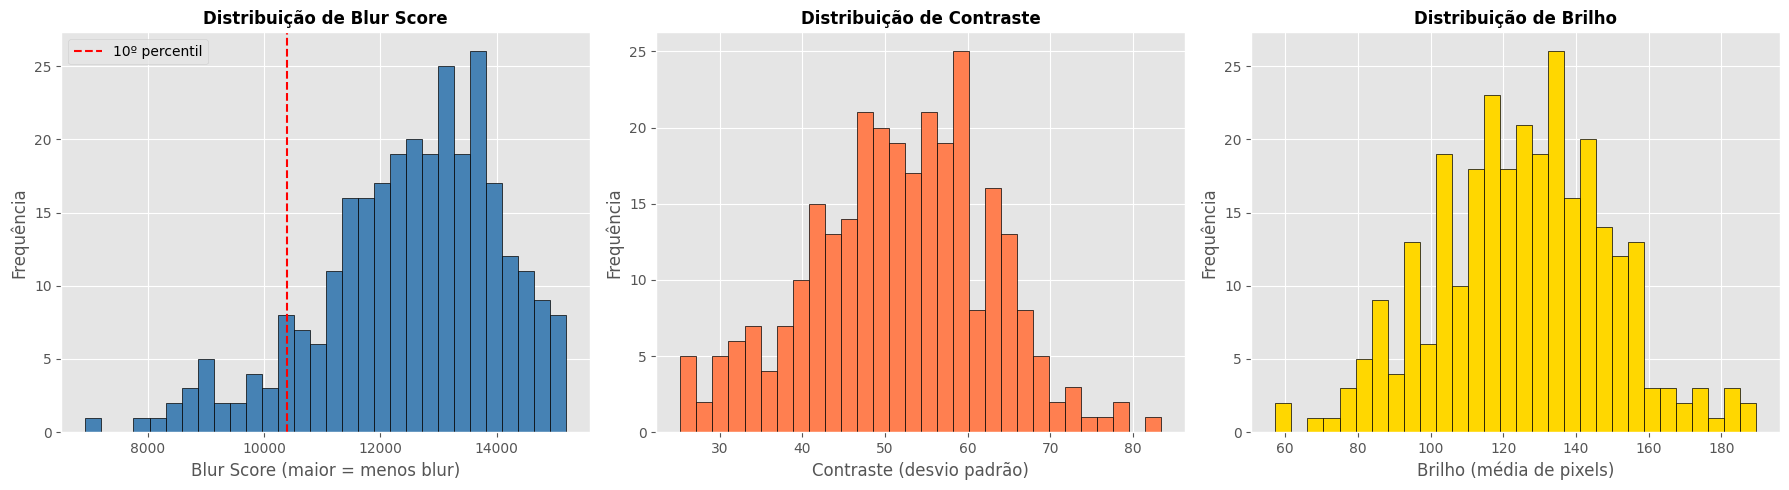

In [ ]:
# Visualizar distribuições de qualidade
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(quality_df['blur_score'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribuição de Blur Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Blur Score (maior = menos blur)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(quality_df['blur_score'].quantile(0.1), color='red', linestyle='--', label='10º percentil')
axes[0].legend()

axes[1].hist(quality_df['contrast'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribuição de Contraste', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contraste (desvio padrão)')
axes[1].set_ylabel('Frequência')

axes[2].hist(quality_df['brightness'], bins=30, color='gold', edgecolor='black')
axes[2].set_title('Distribuição de Brilho', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Brilho (média de pixels)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

Foram analisadas 290 imagens quanto à qualidade visual. O blur score médio foi 12.514, indicando que a maioria das imagens apresenta boa nitidez, com pouca ocorrência de imagens significativamente desfocadas. O contraste médio foi 51,64, demonstrando variação moderada, mas com distribuição relativamente equilibrada entre as amostras. Já o brilho médio foi 125,38, sugerindo predominância de imagens com iluminação adequada, embora existam casos mais escuros e mais claros. De modo geral, o conjunto apresenta qualidade visual consistente, com variações naturais, mas sem indícios de problemas generalizados.

  ### 3.5 Análise dos Valores de Pixel das Máscaras

In [4]:
from PIL import Image
import numpy as np
import os
from collections import Counter

# Coleta todos os valores únicos de pixel encontrados nas máscaras
all_unique_values = set()
value_counts = Counter()

for mask_name in os.listdir(MASK_DIR):
    mask_path = os.path.join(MASK_DIR, mask_name)
    mask = np.array(Image.open(mask_path).convert('L'))
    unique_vals = np.unique(mask)
    all_unique_values.update(unique_vals.tolist())
    for v in unique_vals:
        value_counts[int(v)] += 1

print("Valores únicos encontrados nas máscaras:", sorted(all_unique_values))
print(f"\nTotal de valores distintos: {len(all_unique_values)}")
print("\nQuantas máscaras contêm cada valor:")
for val in sorted(value_counts):
    print(f"  Valor {val:3d}: presente em {value_counts[val]:3d} máscaras")

Valores únicos encontrados nas máscaras: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213

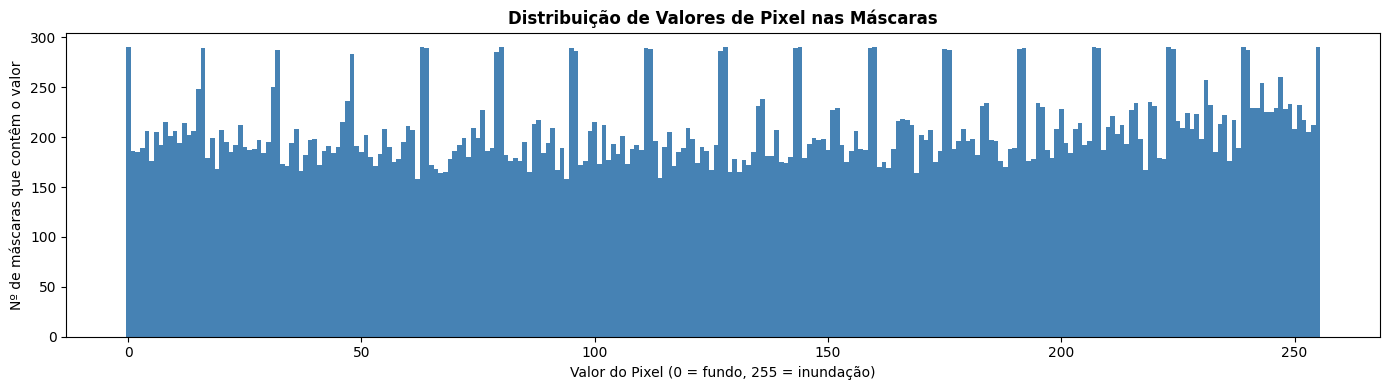

In [8]:
import matplotlib.pyplot as plt
import numpy as np

valores = sorted(value_counts.keys())
contagens = [value_counts[v] for v in valores]

plt.figure(figsize=(14, 4))
plt.bar(valores, contagens, color='steelblue', width=1.0)
plt.title('Distribuição de Valores de Pixel nas Máscaras', fontweight='bold')
plt.xlabel('Valor do Pixel (0 = fundo, 255 = inundação)')
plt.ylabel('Nº de máscaras que contêm o valor')
plt.tight_layout()
plt.show()

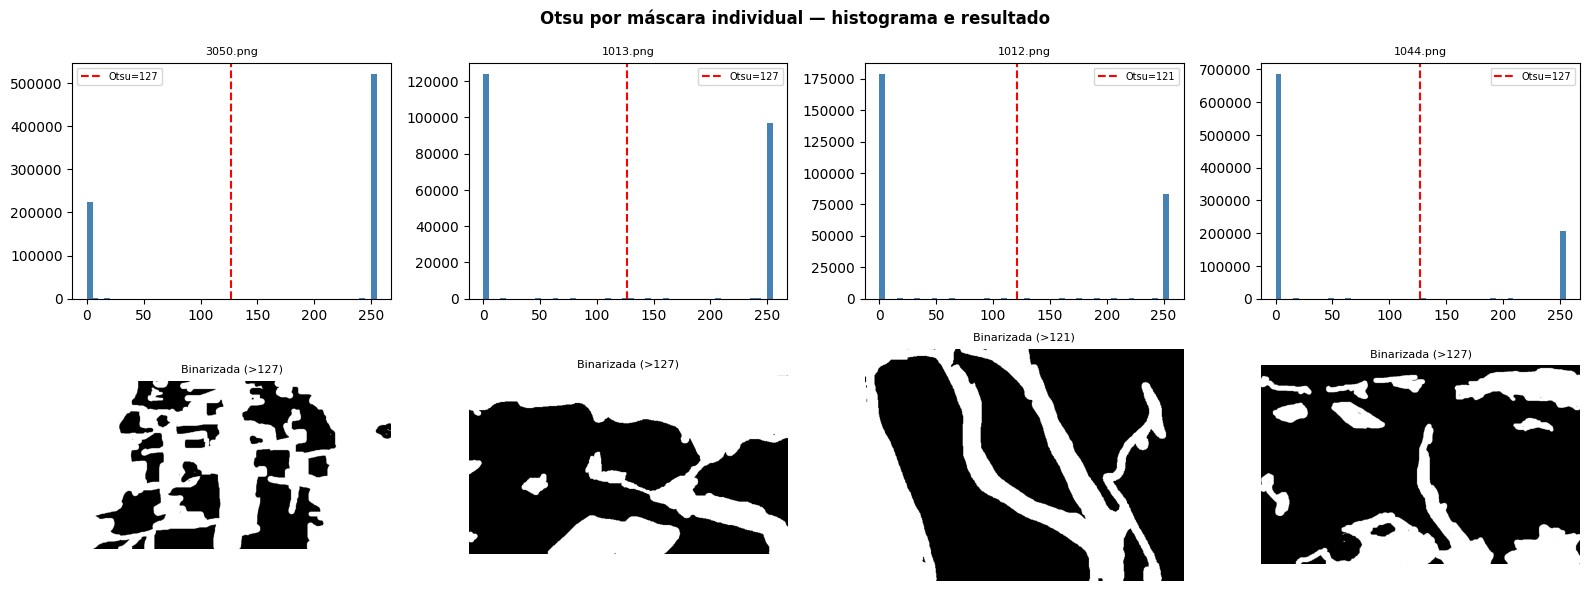

In [6]:
from PIL import Image
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
import random
import os

# Visualizar histograma de 4 máscaras individuais
sample_masks = random.sample(sorted(os.listdir(MASK_DIR)), 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, mask_name in enumerate(sample_masks):
    mask = np.array(Image.open(os.path.join(MASK_DIR, mask_name)).convert('L'))
    thresh = threshold_otsu(mask)
    mask_bin = (mask > thresh).astype(np.uint8) * 255

    # Histograma
    axes[0, i].hist(mask.ravel(), bins=50, color='steelblue')
    axes[0, i].axvline(thresh, color='red', linestyle='--', label=f'Otsu={thresh:.0f}')
    axes[0, i].set_title(mask_name, fontsize=8)
    axes[0, i].legend(fontsize=7)

    # Máscara binarizada
    axes[1, i].imshow(mask_bin, cmap='gray')
    axes[1, i].set_title(f'Binarizada (>{thresh:.0f})', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Otsu por máscara individual — histograma e resultado', fontweight='bold')
plt.tight_layout()
plt.show()

Threshold médio:   125.7
Desvio padrão:     3.4
Mínimo:            112
Máximo:            129
Máscaras com threshold entre 120-135: 273 de 290


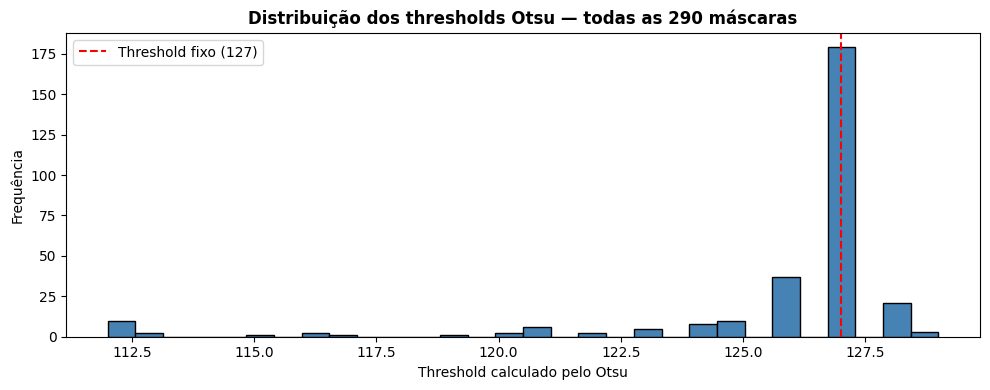

In [11]:
from PIL import Image
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
import os

thresholds = []

for mask_name in sorted(os.listdir(MASK_DIR)):
    mask = np.array(Image.open(os.path.join(MASK_DIR, mask_name)).convert('L'))
    thresh = threshold_otsu(mask)
    thresholds.append(thresh)

thresholds = np.array(thresholds)

print(f"Threshold médio:   {thresholds.mean():.1f}")
print(f"Desvio padrão:     {thresholds.std():.1f}")
print(f"Mínimo:            {thresholds.min()}")
print(f"Máximo:            {thresholds.max()}")
print(f"Máscaras com threshold entre 120-135: {((thresholds >= 120) & (thresholds <= 135)).sum()} de {len(thresholds)}")

plt.figure(figsize=(10, 4))
plt.hist(thresholds, bins=30, color='steelblue', edgecolor='black')
plt.axvline(127, color='red', linestyle='--', label='Threshold fixo (127)')
plt.title('Distribuição dos thresholds Otsu — todas as 290 máscaras', fontweight='bold')
plt.xlabel('Threshold calculado pelo Otsu')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

As máscaras do dataset apresentam histograma fortemente bimodal, com pixels concentrados nos valores 0 (fundo) e 255 (inundação) e quantidade desprezível de valores intermediários, originados da suavização de bordas durante o processo de anotação.

O método de Otsu foi aplicado individualmente nas 290 máscaras para determinar o threshold ótimo de binarização. Os resultados mostram forte consistência: threshold médio de 125,7 (desvio padrão de apenas 3,4), com valores entre 112 e 129, e 273 das 290 máscaras (94,1%) apresentando threshold entre 120 e 135.

Isso confirma que um threshold fixo de 127 é equivalente ao Otsu adaptativo para este dataset e suficiente para a etapa de pré-processamento. A binarização será aplicada como `(mask > 127)` — pixels acima de 127 classificados como  inundação (1), demais como fundo (0).

## 4 - Distribuição de Classes

### 4.1 - Verificação da distribuição de classes para identificar possíveis desiquilíbrios

#### Pixel-level distribution

Abaixo no código, é realizada a análise da distribuição de classes com base na contagem de pixels (pixel-level distribution), procurando identificar possíveis desequilíbrios que possam influenciar o desempenho do modelo, em outras palavras, verificando se a proporção entre valores 0 e 1 estão adequadas no dataset inteiro.

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Variáveis acumuladoras para contar pixels no dataset inteiro
total_pixels = 0
flood_pixels = 0
background_pixels = 0

# Percorre todas as máscaras do dataset
for mask_name in tqdm(os.listdir(MASK_DIR), desc="Processando máscaras"):
  mask_path = os.path.join(MASK_DIR, mask_name)

  # Abre a máscara como imagem e converte para array numpy
  mask = np.array(Image.open(mask_path))

  # Binariza a máscara:
  # qualquer valor > 0 vira 1 (inundação)
  # 0 permanece 0 (fundo)
  mask = (mask > 0).astype(np.uint8)

  # Conta pixels de cada classe
  flood_pixels += np.sum(mask == 1)
  background_pixels += np.sum(mask == 0)

  # Soma o total de pixels processados
  total_pixels += mask.size


print("\nTotal de pixels:", total_pixels)
print("Pixels de Fundo (classe 0):", background_pixels)
print("Pixels de Inundação (classe 1):", flood_pixels)

# Calcula porcentagem de cada classe
fundo_pct = (background_pixels / total_pixels) * 100
flood_pct = (flood_pixels / total_pixels) * 100

print("\nDistribuição percentual:")
print(f"Fundo: {fundo_pct:.2f}%")
print(f"Inundação: {flood_pct:.2f}%")

Processando máscaras: 100%|██████████| 290/290 [00:03<00:00, 87.77it/s]


Total de pixels: 398254854
Pixels de Fundo (classe 0): 215482991
Pixels de Inundação (classe 1): 182771863

Distribuição percentual:
Fundo: 54.11%
Inundação: 45.89%


A distribuição de classes que foi analisada com base na proporção de pixels das máscaras mostra que a classe de fundo (valor 0) representa 54,11% dos pixels, enquanto a classe de inundação (valor 1) corresponde a 45,89%. Esses valores indicam um conjunto de dados equilibrado, sem desequilíbrio significativo entre as classes.

#### Image-level distribution

O código abaixo mostra outra técnica para uma análise da distribuição de classes chamada image-level distribution, onde se verifica quantas imagens do dataset contêm pelo menos um pixel (ou uma porcentagem mínima) de inundação e quantas são puramente fundo (apenas terra/cidade seca).

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Variáveis acumuladoras para contar imagens no dataset inteiro
images_with_flood = 0
images_without_flood = 0

# Percorre todas as máscaras do dataset
for mask_name in tqdm(os.listdir(MASK_DIR), desc="Analisando imagens"):
    mask_path = os.path.join(MASK_DIR, mask_name)

    # Abre a máscara como imagem e converte para array numpy
    mask = np.array(Image.open(mask_path))

    # Binariza a máscara:
    # qualquer valor > 0 vira 1 (inundação)
    # 0 permanece 0 (fundo)
    mask = (mask > 0).astype(np.uint8)

    # Conta as imagens de cada classe
    if np.any(mask == 1):
        images_with_flood += 1
    else:
        images_without_flood += 1

# Soma o total de pixels processados
total_images = images_with_flood + images_without_flood

print("\nTotal de imagens:", total_images)
print("Imagens COM inundação:", images_with_flood)
print("Imagens SEM inundação:", images_without_flood)

# Calcula porcentagem de cada classe
flood_pct = (images_with_flood / total_images) * 100
fundo_pct = (images_without_flood / total_images) * 100

print("\nProporção:")
print(f"Com inundação: {flood_pct:.2f}%")
print(f"Sem inundação: {fundo_pct:.2f}%")

Analisando imagens: 100%|██████████| 290/290 [00:02<00:00, 129.11it/s]


Total de imagens: 290
Imagens COM inundação: 290
Imagens SEM inundação: 0

Proporção:
Com inundação: 100.00%
Sem inundação: 0.00%


A análise em nível de imagem mostra que 100% das amostras contêm pixels da classe de inundação, ou seja, não existem imagens vazias no conjunto de dados.

#### Connected Components

Outra técnica é conhecida como Connected Components que é utilizada para medir a complexidade espacial da classe segmentada, identificando se os pixels de inundação formam regiões contínuas ou várias “ilhas” isoladas. Essa análise permite caracterizar o grau de fragmentação das máscaras, indicando se o modelo precisará aprender padrões mais suaves ou muitos detalhes finos. Assim, quanto maior o número de regiões pequenas e desconectadas, maior tende a ser a complexidade geométrica do problema de segmentação.

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import label

# Lista que vai guardar quantos componentes existem em cada imagem
components_per_image = []

# Lista que vai guardar a área (número de pixels) de cada componente individual
area_per_component = []

# Percorre todos os arquivos dentro da pasta de máscaras
for mask_name in tqdm(os.listdir(MASK_DIR), desc="Connected Components"):
    mask_path = os.path.join(MASK_DIR, mask_name)

    # Abre a imagem da máscara e converte para array NumPy
    mask = np.array(Image.open(mask_path))

    # Binariza a máscara:
    # tudo que for > 0 vira 1 (objeto)
    # o resto vira 0 (fundo)
    mask = (mask > 0).astype(np.uint8)

    # Rotula os componentes conectados
    # labeled: imagem onde cada componente recebe um ID (1,2,3...)
    # num_components: quantidade total de componentes encontrados
    labeled, num_components = label(mask)

    # Guarda quantos componentes essa imagem tem
    components_per_image.append(num_components)

    # Para cada componente encontrado
    for i in range(1, num_components + 1):
        # Conta quantos pixels pertencem a esse componente
        area = np.sum(labeled == i)

        # Guarda a área na lista geral
        area_per_component.append(area)

# Estatísticas finais do conjunto de imagens
print("\nTotal de imagens:", len(components_per_image))
print("Média de componentes por imagem:", np.mean(components_per_image))
print("Máximo de componentes em uma imagem:", np.max(components_per_image))
print("Mínimo de componentes:", np.min(components_per_image))

Connected Components: 100%|██████████| 290/290 [00:12<00:00, 22.43it/s]


Total de imagens: 290
Média de componentes por imagem: 13.13103448275862
Máximo de componentes em uma imagem: 81
Mínimo de componentes: 1


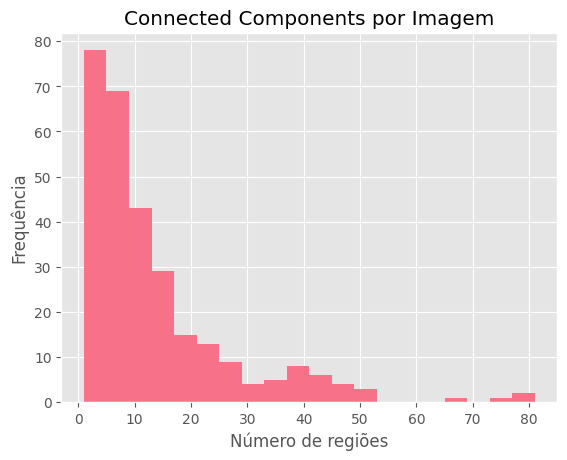

In [ ]:
import matplotlib.pyplot as plt

plt.hist(components_per_image, bins=20)
plt.title("Connected Components por Imagem")
plt.xlabel("Número de regiões")
plt.ylabel("Frequência")
plt.show()

A análise de componentes conectados indica que as máscaras apresentam múltiplas regiões independentes de inundação por imagem, com média de aproximadamente 13 componentes. Isso evidencia que o dataset possui fragmentação espacial relevante, exigindo que o modelo aprenda a segmentar diversas regiões descontínuas dentro de uma mesma amostra. A presença de uma cauda longa na distribuição indica variação estrutural entre as imagens, aumentando a diversidade geométrica do problema.

#### Spatial Heatmap

Mais uma técnica importante é a Spatial Heatmap, onde sobrepomos todas as máscaras do dataset umas sobre as outras para obter um "mapa de calor" médio de onde temos mais pixels de indunção no dataset. É importante para verificar vieses de posição, ou seja, se as inundações aparecem sempre no centro da imagem ou na parte inferior por exemplo, o modelo pode aprender a ignorar as bordas.

Spatial Heatmap: 100%|██████████| 290/290 [00:01<00:00, 148.55it/s]


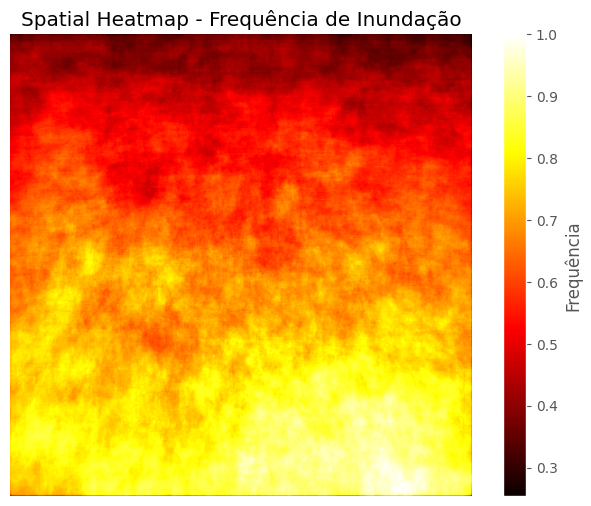

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# Definimos um tamanho padrão para todas as máscaras.
# Isso é necessário porque o dataset possui imagens com resoluções diferentes.
# Para somar as máscaras e gerar o heatmap, todas precisam ter o mesmo shape.
TARGET_SIZE = (512, 512)

# Matriz acumuladora onde vamos somar a presença de inundação
# em cada posição espacial ao longo do dataset inteiro.
heatmap = np.zeros(TARGET_SIZE, dtype=np.float32)

for mask_name in tqdm(os.listdir(MASK_DIR), desc="Spatial Heatmap"):
    mask_path = os.path.join(MASK_DIR, mask_name)

    # Abre a máscara em escala de cinza
    mask = Image.open(mask_path).convert("L")

    # Redimensiona para o tamanho padrão.
    # Usamos NEAREST para preservar rótulos binários (segmentação),
    # evitando interpolação que misturaria classes.
    mask = mask.resize(TARGET_SIZE, Image.NEAREST)

    # Converte para numpy
    mask = np.array(mask)

    # Binariza: 1 = inundação, 0 = fundo
    mask = (mask > 0).astype(np.float32)

    # Soma no heatmap:
    # cada pixel acumula quantas vezes houve inundação naquela posição
    heatmap += mask

# Normaliza para o intervalo [0,1]
# Isso transforma a soma em frequência relativa
heatmap /= np.max(heatmap)

# Visualização do mapa de calor espacial
plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='hot')
plt.title("Spatial Heatmap - Frequência de Inundação")
plt.colorbar(label="Frequência")
plt.axis('off')
plt.show()

A análise revela forte concentração das áreas inundadas na porção inferior das imagens. Esse padrão sugere que o modelo pode explorar informação posicional durante o treinamento, o que pode impactar a capacidade de generalização para cenários com enquadramento diferente, "ignorando" a porção superior das imagens.

## 5. Detecção de Imagens Duplicadas

In [ ]:
import hashlib
from collections import defaultdict

def find_duplicate_images(image_dir):
    """
    Encontra imagens duplicadas usando hash MD5.
    """
    print("Procurando imagens duplicadas...\n")

    hash_dict = defaultdict(list)

    for img_file in os.listdir(image_dir):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(image_dir, img_file)

        try:
            # Calcular hash MD5 do arquivo
            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_dict[file_hash].append(img_file)

        except Exception as e:
            print(f"Erro ao processar {img_file}: {e}")

    # Encontrar duplicatas
    duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

    print("="*60)
    print("RESULTADOS DA VERIFICAÇÃO DE DUPLICATAS")
    print("="*60)

    if len(duplicates) == 0:
        print("\nNenhuma imagem duplicada encontrada!")
    else:
        print(f"\n{len(duplicates)} grupos de imagens duplicadas encontrados:\n")
        for i, (hash_val, files) in enumerate(duplicates.items(), 1):
            print(f"Grupo {i} ({len(files)} arquivos):")
            for f in files:
                print(f"   - {f}")
            print()

    return duplicates

# Executar detecção de duplicatas
duplicates_found = find_duplicate_images(IMAGE_DIR)

Procurando imagens duplicadas...

RESULTADOS DA VERIFICAÇÃO DE DUPLICATAS

8 grupos de imagens duplicadas encontrados:

Grupo 1 (2 arquivos):
   - 1026.jpg
   - 18.jpg

Grupo 2 (2 arquivos):
   - 1041.jpg
   - 3033.jpg

Grupo 3 (2 arquivos):
   - 1012.jpg
   - 1057.jpg

Grupo 4 (2 arquivos):
   - 1044.jpg
   - 46.jpg

Grupo 5 (2 arquivos):
   - 43.jpg
   - 1021.jpg

Grupo 6 (2 arquivos):
   - 3019.jpg
   - 1049.jpg

Grupo 7 (2 arquivos):
   - 26.jpg
   - 3020.jpg

Grupo 8 (2 arquivos):
   - 3029.jpg
   - 1033.jpg



In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_duplicate_group(image_dir, duplicate_group):
    """
    Mostra imagens duplicadas lado a lado para comparação.
    """

    n = len(duplicate_group)
    plt.figure(figsize=(5*n, 5))

    for i, img_name in enumerate(duplicate_group):
        img_path = os.path.join(image_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

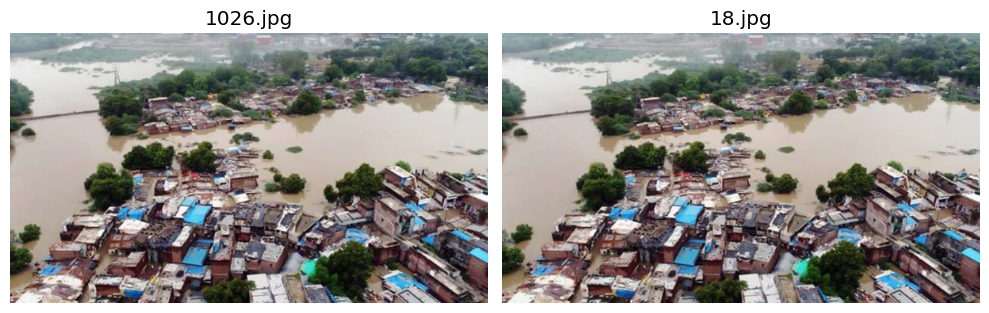

In [ ]:
# Pegando o primeiro grupo encontrado
first_group = list(duplicates_found.values())[0]

show_duplicate_group(IMAGE_DIR, first_group)

A verificação identificou 8 grupos de imagens duplicadas, cada um contendo dois arquivos idênticos, totalizando 16 imagens repetidas no dataset. Essas duplicatas podem gerar viés em análises ou no treinamento de modelos, sendo recomendada a remoção de uma imagem por grupo para evitar redundância e possíveis impactos nos resultados.